# Product Data Analytics & Exploration

**Objective:** To load, clean, and analyze the `intern_data_ikarus.csv` dataset to uncover insights that will be displayed on the Analytics page of our web app.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast  # To safely evaluate string-formatted lists

# Set plot style
sns.set_style('whitegrid')


## 1. Load and Inspect Data


In [3]:
df = pd.read_csv('intern_data_ikarus.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   title               312 non-null    object
 1   brand               312 non-null    object
 2   description         159 non-null    object
 3   price               215 non-null    object
 4   categories          312 non-null    object
 5   images              312 non-null    object
 6   manufacturer        205 non-null    object
 7   package_dimensions  306 non-null    object
 8   country_of_origin   125 non-null    object
 9   material            218 non-null    object
 10  color               265 non-null    object
 11  uniq_id             312 non-null    object
dtypes: object(12)
memory usage: 29.4+ KB


In [4]:
df.head()


,title,brand,description,price,categories,images,manufacturer,package_dimensions,country_of_origin,material,color,uniq_id
0,"GOYMFK 1pc Free Standing Shoe Rack, Multi-laye...",GOYMFK,"multiple shoes, coats, hats, and other items E...",$24.99,"['Home & Kitchen', 'Storage & Organization', '...",['https://m.media-amazon.com/images/I/416WaLx1...,GOYMFK,"2.36""D x 7.87""W x 21.6""H",China,Metal,White,02593e81-5c09-5069-8516-b0b29f439ded
1,"subrtex Leather ding Room, Dining Chairs Set o...",subrtex,subrtex Dining chairs Set of 2,NaN,"['Home & Kitchen', 'Furniture', 'Dining Room F...",['https://m.media-amazon.com/images/I/31SejUEW...,Subrtex Houseware INC,"18.5""D x 16""W x 35""H",NaN,Sponge,Black,5938d217-b8c5-5d3e-b1cf-e28e340f292e
2,Plant Repotting Mat MUYETOL Waterproof Transpl...,MUYETOL,NaN,$5.98,"['Patio, Lawn & Garden', 'Outdoor Décor', 'Doo...",['https://m.media-amazon.com/images/I/41RgefVq...,MUYETOL,"26.8""L x 26.8""W",NaN,Polyethylene,Green,b2ede786-3f51-5a45-9a5b-bcf856958cd8
3,"Pickleball Doormat, Welcome Doormat Absorbent ...",VEWETOL,The decorative doormat features a subtle textu...,$13.99,"['Patio, Lawn & Garden', 'Outdoor Décor', 'Doo...",['https://m.media-amazon.com/images/I/61vz1Igl...,Contrence,"24""L x 16""W",NaN,Rubber,A5589,8fd9377b-cfa6-5f10-835c-6b8eca2816b5
4,JOIN IRON Foldable TV Trays for Eating Set of ...,JOIN IRON Store,Set of Four Folding Trays With Matching Storag...,$89.99,"['Home & Kitchen', 'Furniture', 'Game & Recrea...",['https://m.media-amazon.com/images/I/41p4d4VJ...,NaN,"18.9""D x 14.2""W x 26""H",NaN,Iron,Grey Set of 4,bdc9aa30-9439-50dc-8e89-213ea211d66a


## 2. Data Cleaning and Preprocessing

The following steps are crucial for making the data usable:
1. **Price Column:** Convert the price from a string (e.g., `$24.99`) to a numeric type.  
2. **List-like Columns:** The `categories` and `images` columns are strings that look like lists. We need to parse them into actual lists.  
3. **Handle Missing Values:** Check for and decide on a strategy for any `NaN` values.


In [5]:
# Clean price column
df['price_numeric'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

# Function to safely parse string-formatted lists
def parse_string_list(s):
    try:
        return ast.literal_eval(s)
    except (ValueError, SyntaxError):
        return []

# Apply parsing
df['categories_list'] = df['categories'].apply(parse_string_list)
df['images_list'] = df['images'].apply(parse_string_list)

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
title                   0
brand                   0
description           153
price                  97
categories              0
images                  0
manufacturer          107
package_dimensions      6
country_of_origin     187
material               94
color                  47
uniq_id                 0
price_numeric          97
categories_list         0
images_list             0
dtype: int64


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
/var/folders/mz/98ctw4990_98lwy5yjc4560w0000gn/T/ipykernel_29975/4067711131.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['price_numeric'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


## 3. Exploratory Data Analysis (EDA)

Now we can derive some insights. These results can be saved to a JSON file to be served by our FastAPI backend.


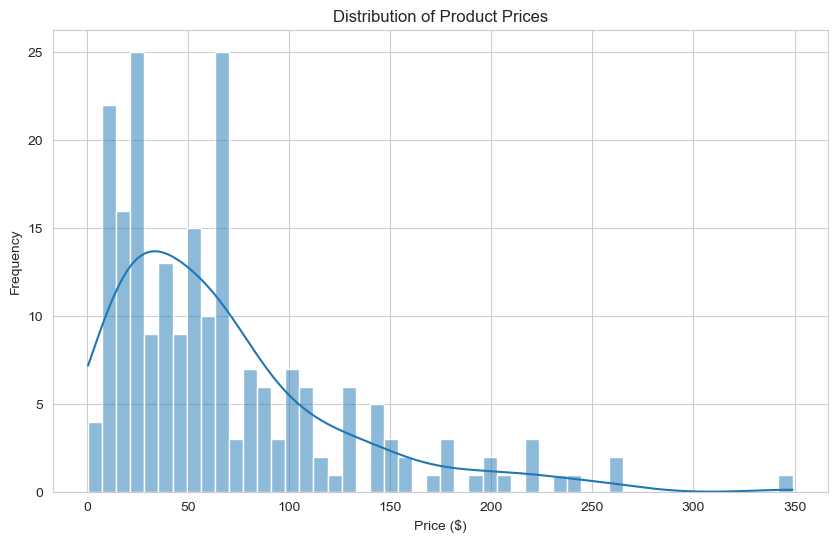

In [6]:
# Price Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['price_numeric'], bins=50, kde=True)
plt.title('Distribution of Product Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()


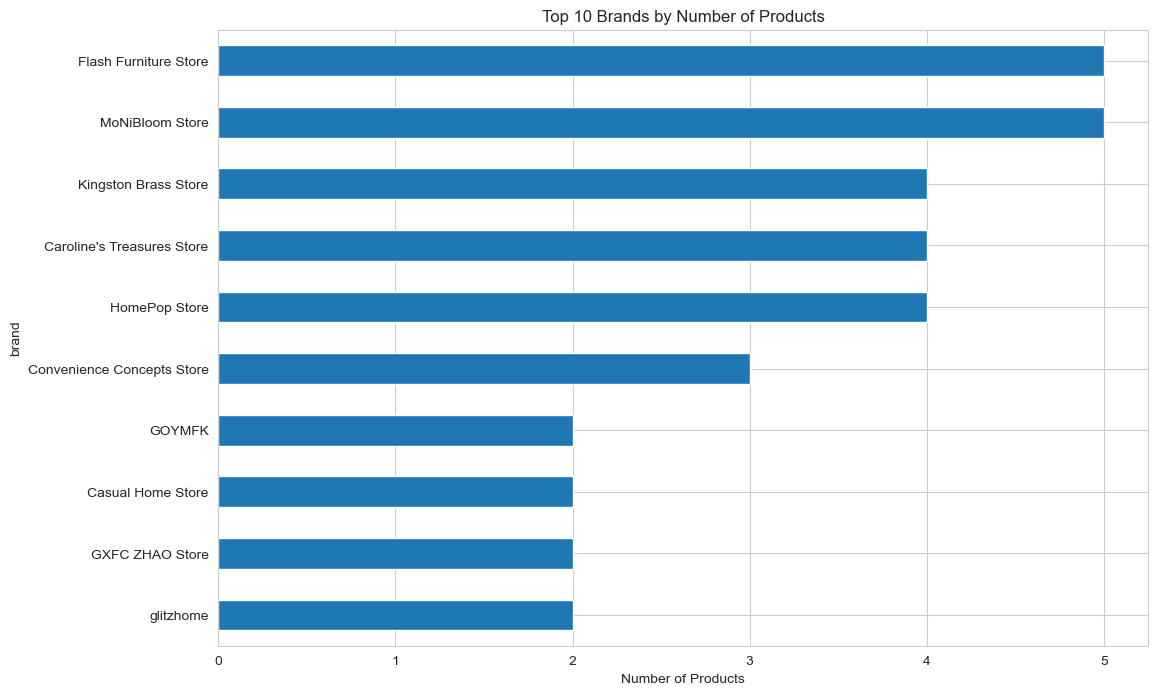

In [7]:
# Top 10 Brands
plt.figure(figsize=(12, 8))
df['brand'].value_counts().nlargest(10).plot(kind='barh')
plt.title('Top 10 Brands by Number of Products')
plt.xlabel('Number of Products')
plt.gca().invert_yaxis()
plt.show()


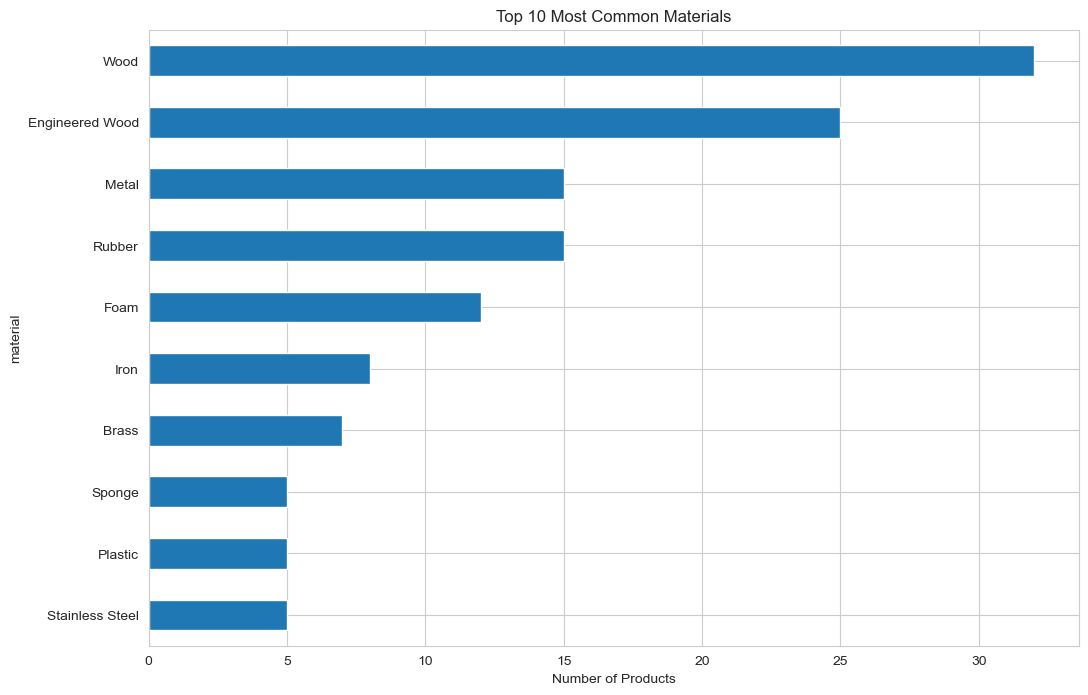

In [8]:
# Top Materials
plt.figure(figsize=(12, 8))
df['material'].value_counts().nlargest(10).plot(kind='barh')
plt.title('Top 10 Most Common Materials')
plt.xlabel('Number of Products')
plt.gca().invert_yaxis()
plt.show()


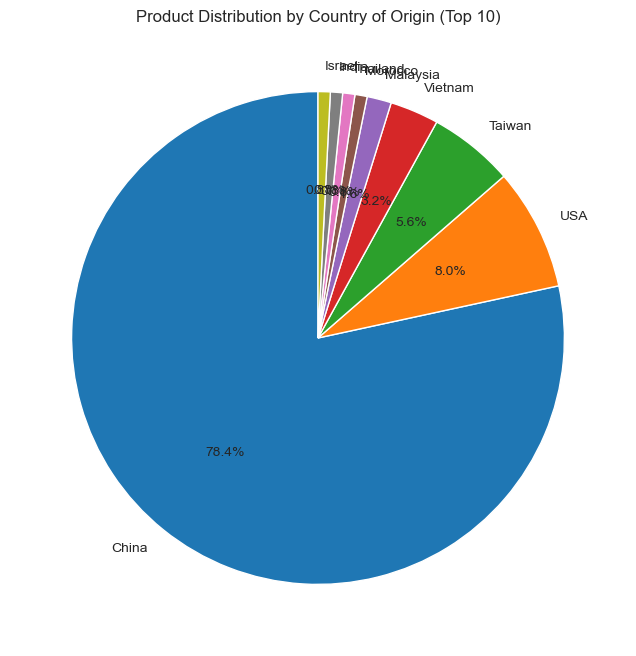

In [9]:
# Analysis of Country of Origin
plt.figure(figsize=(12, 8))
df['country_of_origin'].value_counts().nlargest(10).plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Product Distribution by Country of Origin (Top 10)')
plt.ylabel('')
plt.show()


## 4. Prepare Analytics Data for Backend

We'll save these aggregated insights into a JSON file that our FastAPI backend can easily read and serve to the frontend.


In [10]:
import json

top_brands = df['brand'].value_counts().nlargest(10).to_dict()
top_materials = df['material'].value_counts().nlargest(10).to_dict()
top_countries = df['country_of_origin'].value_counts().nlargest(10).to_dict()

analytics_data = {
    'price_summary': df['price_numeric'].describe().to_dict(),
    'top_brands': top_brands,
    'top_materials': top_materials,
    'top_countries': top_countries
}

with open('analytics_output.json', 'w') as f:
    json.dump(analytics_data, f, indent=4)

print("Analytics data saved to analytics_output.json")


Analytics data saved to analytics_output.json
